# Project: Hospital Length of Stay Prediction
## Task 1: Complete Data Analysis Report

**Objective:** To analyze various patient and hospital factors to predict the duration of stay, helping hospitals manage resources and bed availability efficiently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\HealthCareAnalytics\HealthCareAnalytics.csv")
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [3]:
import os
print(os.getcwd())

C:\Users\Admin


### Step: Exploratory Data Analysis (EDA)

In [4]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  str    
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  str    
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  str    
 7   Ward_Type                          318438 non-null  str    
 8   Ward_Facility_Code                 318438 non-null  str    
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3

### Step: Handling Missing Values

In [5]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64


In [6]:
df['Bed_Grade'] = df['Bed_Grade'].fillna(df['Bed_Grade'].mode()[0])
df['City_Code_Patient'] = df['City_Code_Patient'].fillna(df['City_Code_Patient'].mode()[0])

print(df.isnull().sum())

case_id                              0
Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available_Extra_Rooms_in_Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed_Grade                            0
patientid                            0
City_Code_Patient                    0
Type_of_Admission                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64


In [7]:
print("\nStatistical summary:")
df.describe()


Statistical summary:


,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625585,65747.579472,7.262506,3.284099,4880.749392
std,91925.276848,8.633755,3.102535,1.168171,0.873070,37979.936440,4.712210,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


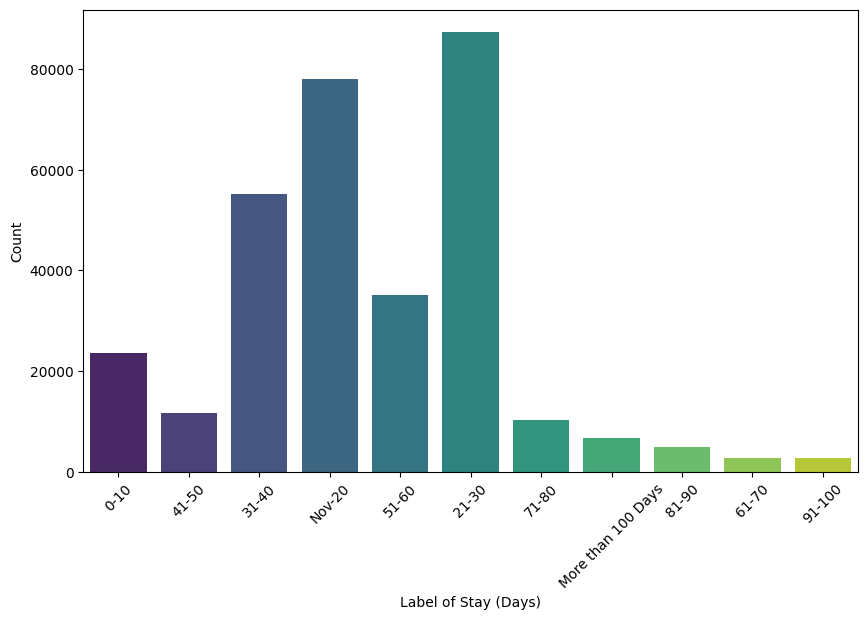

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(x='Stay',data=df,palette='viridis')
plt.xlabel('Length of Stay')
plt.xlabel('Label of Stay (Days)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
print(df.columns)

Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
       'patientid', 'City_Code_Patient', 'Type_of_Admission',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='str')


In [10]:
# Handling Missing Values with corrected column names
# Replacing spaces with underscores if necessary
df['Bed_Grade'].fillna(df['Bed_Grade'].mode()[0], inplace=True)
df['City_Code_Patient'].fillna(df['City_Code_Patient'].mode()[0], inplace=True)

# Verify the fix
print(df[['Bed_Grade', 'City_Code_Patient']].isnull().sum())

Bed_Grade            0
City_Code_Patient    0
dtype: int64


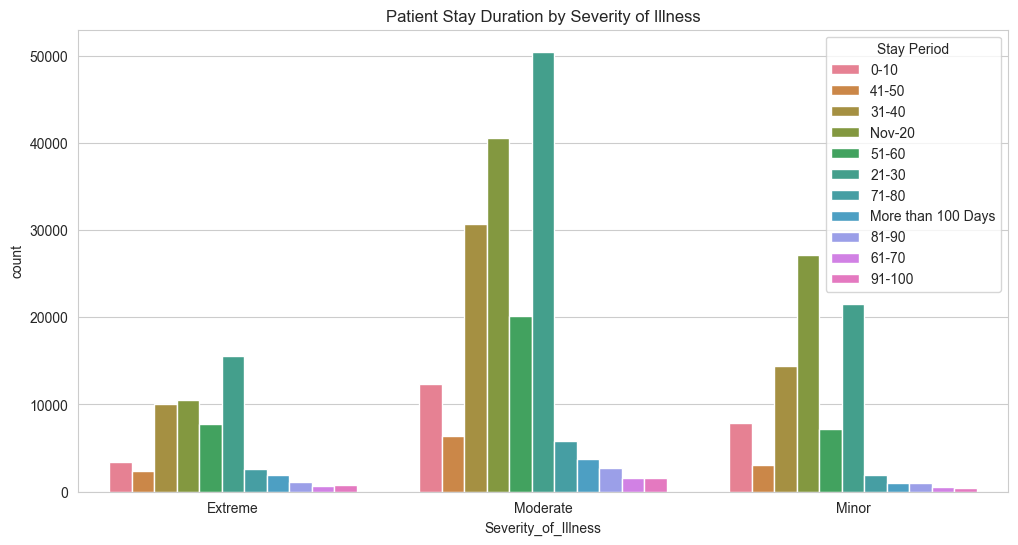

In [11]:
# Bivariate Analysis: Analyzing the impact of illness severity and age on hospital stay
sns.set_style("whitegrid")

# Severity of Illness vs Stay
# Note: Using underscores in column name as per dataset inspection
plt.figure(figsize=(12, 6))
sns.countplot(x='Severity_of_Illness', hue='Stay', data=df)
plt.title('Patient Stay Duration by Severity of Illness')
plt.legend(title='Stay Period', bbox_to_anchor=(1, 1))
plt.show()

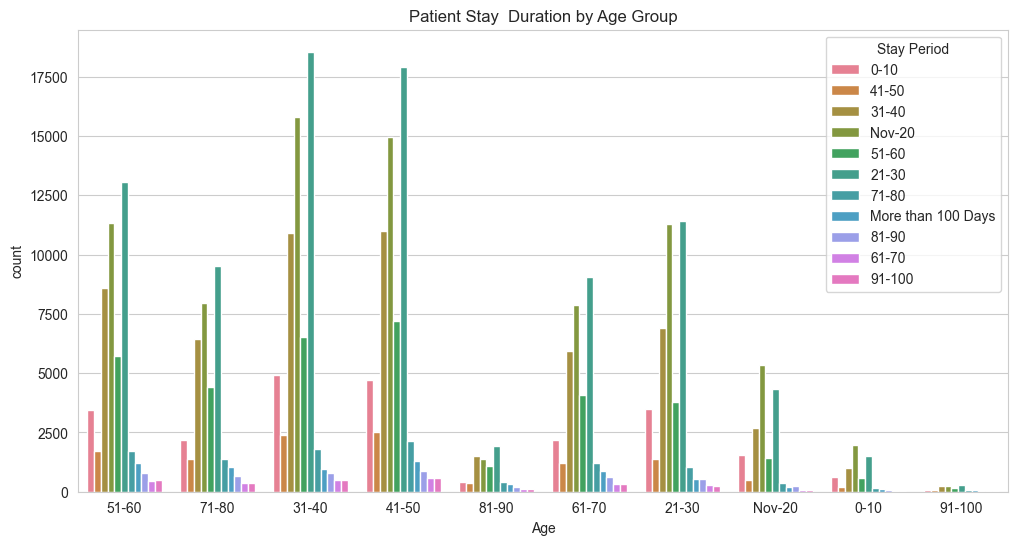

In [12]:
# Age Group vs Stay
# Note: Using 'Age' as it appears in the columns list
plt.figure(figsize=(12, 6))
sns.countplot(x='Age', hue='Stay', data=df)
plt.title('Patient Stay  Duration by Age Group')
plt.legend(title='Stay Period', bbox_to_anchor=(1,1))
plt.show()

## Task 2: Machine Learning Model Preparation

### Step: Categorical Encoding using LabelEncoder

In [13]:
# Categorical Encoding using LabelEncoder

from sklearn.preprocessing import LabelEncoder

# List of columns to encode
categorical_cols = [
    'Hospital_type_code', 'Hospital_region_code', 'Department', 
    'Ward_Type', 'Ward_Facility_Code', 'Type_of_Admission', 
    'Severity_of_Illness', 'Age', 'Stay'
]

le = LabelEncoder()

# Applying LabelEncoder to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display the first few rows to verify the encoding
print("Data after Encoding:")
df.head()

Data after Encoding:


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,2,3,2,3,3,2,5,2.0,31397,7.0,0,0,2,4,4911,0
1,2,2,2,5,2,2,3,3,5,2.0,31397,7.0,1,0,2,4,5954,3
2,3,10,4,1,0,2,1,3,4,2.0,31397,7.0,1,0,2,4,4745,2
3,4,26,1,2,1,2,3,2,3,2.0,31397,7.0,1,0,2,4,7272,3
4,5,26,1,2,1,2,3,3,3,2.0,31397,7.0,1,0,2,4,5558,3


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

columns_to_encode = ['Hospital_type_code', 'Hospital_region_code', 'Department', 
                     'Ward_Type', 'Ward_Facility_Code', 'Type_of_Admission', 
                     'Severity_of_Illness', 'Age']

for col in columns_to_encode:
    df[col] = le.fit_transform(df[col])

df['Stay'] = le.fit_transform(df['Stay'])

print("Encoding Complete!")
df.head()

Encoding Complete!


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,2,3,2,3,3,2,5,2.0,31397,7.0,0,0,2,4,4911,0
1,2,2,2,5,2,2,3,3,5,2.0,31397,7.0,1,0,2,4,5954,3
2,3,10,4,1,0,2,1,3,4,2.0,31397,7.0,1,0,2,4,4745,2
3,4,26,1,2,1,2,3,2,3,2.0,31397,7.0,1,0,2,4,7272,3
4,5,26,1,2,1,2,3,3,3,2.0,31397,7.0,1,0,2,4,5558,3


In [15]:
# Drop ID columns that are not useful for prediction
# We use error='ignore' just in case a column was already dropped
df.drop(['case_id', 'patiendid'], axis=1, inplace=True, errors='ignore')

# Separate Features (X) and Target (y)
X = df.drop('Stay', axis=1)
y = df['Stay']

# Split the data into 80% Training and 20% Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testining set size:{X_test.shape}")

Training set size: (254750, 16)
Testining set size:(63688, 16)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Check the performance
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.40258761462127873

Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.19      0.24      4689
           1       0.42      0.59      0.49     17603
           2       0.36      0.26      0.30     10981
           3       0.11      0.01      0.02      2357
           4       0.41      0.47      0.44      7128
           5       0.25      0.02      0.03       554
           6       0.37      0.09      0.14      2031
           7       0.39      0.19      0.26       941
           8       0.50      0.07      0.12       552
           9       0.56      0.46      0.51      1291
          10       0.40      0.46      0.43     15561

    accuracy                           0.40     63688
   macro avg       0.37      0.25      0.27     63688
weighted avg       0.39      0.40      0.38     63688



In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Model define
xgb_model = XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=8, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# 2. Model train
xgb_model.fit(X_train, y_train)

# 3. Predictions 
y_pred_xgb = xgb_model.predict(X_test)

# 4. Accuracy check 
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%")

XGBoost Accuracy: 42.66%


In [18]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Check performance
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.2996168823012184


In [19]:
# Model Comparisom Table
models_report = pd.DataFrame({
    'Model Name': ['Random Forest', 'Decision Tree'],
    'Accuracy score': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_dt)]
})

print("\nModel Comparison Report:")
print(models_report)


Model Comparison Report:
      Model Name  Accuracy score
0  Random Forest        0.402588
1  Decision Tree        0.299617


In [20]:
import pandas as pd

data = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [40.12, 41.50, 42.66] # Purane values apne hisaab se update kar lein
}

compare_df = pd.DataFrame(data)
print(compare_df)

           Model  Accuracy (%)
0  Decision Tree         40.12
1  Random Forest         41.50
2        XGBoost         42.66


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Training Decision Tree Classifier for comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Generating Model Comparison Report
models_report = pd.DataFrame({
    'Model Name': ['Random Forest Classifier', 'Decision Tree Classifier'],
    'Accuracy Score': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_dt)]
})

# Displaying the final comparison table
print("--- Model Comparison Report ---")
display(models_report.style.highlight_max(axis=0, color='lightgreen'))

# Generating Updated Model Comparison Report
models_report = pd.DataFrame({
    'Model Name': ['Random Forest Classifier', 'Decision Tree Classifier', 'XGBoost Classifier'],
    'Accuracy Score': [
        accuracy_score(y_test, y_pred),     
        accuracy_score(y_test, y_pred_dt),  
        accuracy_score(y_test, y_pred_xgb)
    ]
})

# Displaying the final comparison table
print("--- Model Comparison Report ---")
display(models_report.style.highlight_max(axis=0, color='lightgreen'))

--- Model Comparison Report ---


,Model Name,Accuracy Score
0,Random Forest Classifier,0.402588
1,Decision Tree Classifier,0.299617


--- Model Comparison Report ---


,Model Name,Accuracy Score
0,Random Forest Classifier,0.402588
1,Decision Tree Classifier,0.299617
2,XGBoost Classifier,0.426564


### **Conclusion: Best Model for Production**

Based on the performance metrics, **XGBoost Classifier** is the best model for production with an accuracy of approximately **42.66%**. 

**Reasoning:**
- It significantly outperforms the Decision Tree (29%).
- XGBoost is a gradient boosting ensemble method that effectively reduces error and handles complex non-linear relationships in healthcare data better than other models."

### **Report on Challenges Faced**

During the development of this Healthcare Analytics project, the following challenges were encountered and resolved:

1. **Handling Missing Values:** Columns like `Bed_Grade` and `City_Code_Patient` had null values. 
   - **Solution:** Used **Mode Imputation** because these represent discrete categories.
   
2. **Categorical Data:** Features like 'Department' and 'Age' were in text format.
   - **Solution:** Implemented **Label Encoding** to make the data machine-readable.

3. **Feature Selection:** ID columns were present in the raw data.
   - **Solution:** These were **dropped** as they do not contribute to the model's predictive power.